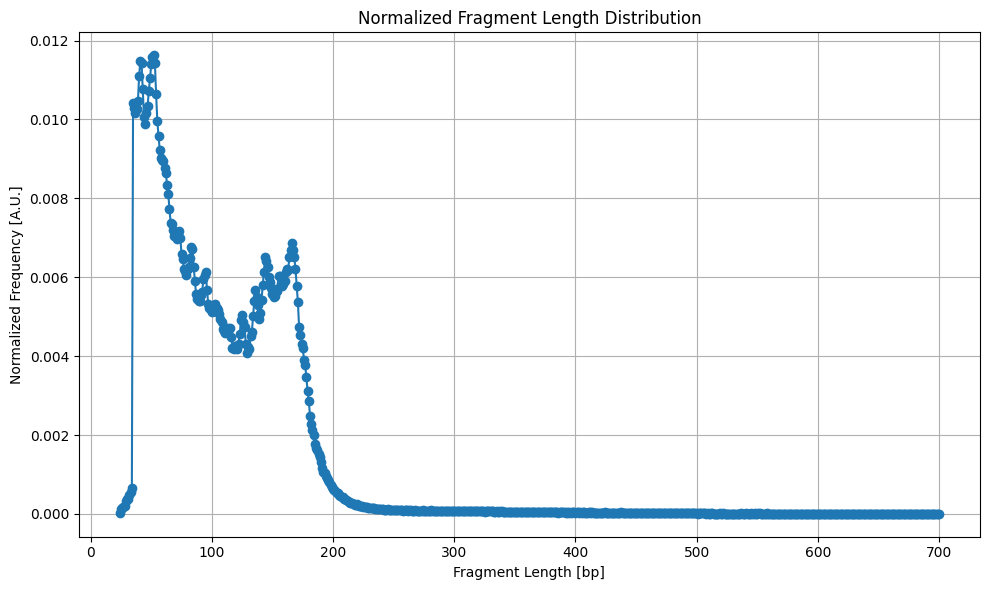

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import gzip
fragment_lengths = []
with gzip.open("query.bed.gz", "rt") as f:  # 'rt' = read as text
    for line in f:
        if line.strip():
            fields = line.strip().split('\t')
            try:
                start = int(fields[1])
                end = int(fields[2])
                fragment_lengths.append(end - start)
            except (IndexError, ValueError):
                continue  # skip malformed lines
# Now lets count the frequency of each Fragment length using the Counter operation
length_counts = Counter(fragment_lengths)
#Now we can normalize the frequencies to values 0-1
total_counts = sum(length_counts.values())
normalized_freqs = {length: count / total_counts for length, count in length_counts.items()}
#Lets sort the values
sorted_lengths = sorted(normalized_freqs.items())
x_vals = [length for length, _ in sorted_lengths]
y_vals = [freq for _, freq in sorted_lengths]
#Now to plot using matplotlib
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, marker='o')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Normalized Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

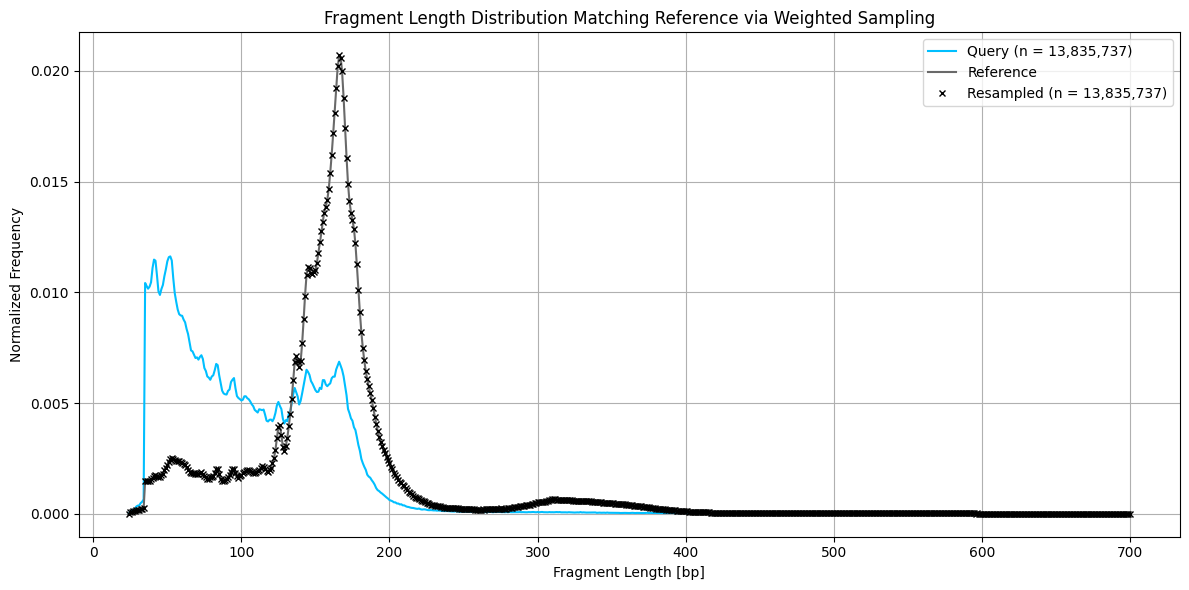

In [5]:
reference_probs = {}
with open("reference.hist", "r") as f:
    for line in f:
        length, prob = line.strip().split('\t')
        reference_probs[int(length)] = float(prob)
# Now to query the histogram of reference
query_counts = Counter(fragment_lengths)
total_query = sum(query_counts.values())
query_freqs = {l: c / total_query for l, c in query_counts.items()}
#Calculating the samling weights
sampling_weights = []
for l in fragment_lengths:
    ref_p = reference_probs.get(l, 1e-9)
    query_p = query_freqs.get(l, 1e-9)
    weight = ref_p / query_p
    sampling_weights.append(weight)
#Normalizing the weights
sampling_weights = np.array(sampling_weights)
sampling_weights = sampling_weights / sampling_weights.sum()
#using complete data and samling with replacement based on weights
n_samples = total_query
resampled_indices = np.random.choice(len(fragment_lengths), size=n_samples, replace=True, p=sampling_weights)
resampled_fragments = [fragment_lengths[i] for i in resampled_indices]
#Making histogram
resampled_counts = Counter(resampled_fragments)
total_resampled = sum(resampled_counts.values())
resampled_freqs = {l: c / total_resampled for l, c in resampled_counts.items()}
#The plotting functions
def plot_distribution(data_dict, label, style, color):
    items = sorted(data_dict.items())
    x = [k for k, _ in items]
    y = [v for _, v in items]
    plt.plot(x, y, style, label=label, color=color)
def plot_distribution2(data_dict, label, style, color, marker=None):
    items = sorted(data_dict.items())
    x = [k for k, _ in items]
    y = [v for _, v in items]
    plt.plot(x, y,
             linestyle=style if style != 'None' else 'None',
             marker=marker,
             label=label,
             color=color,
             markersize=4)
#now to plot the distributions
plt.figure(figsize=(12, 6))
plot_distribution(query_freqs, f"Query (n = {total_query:,})", '-', 'deepskyblue')
plot_distribution(reference_probs, "Reference", 'None', 'dimgrey')
plot_distribution2(resampled_freqs, f"Resampled (n = {total_resampled:,})", 'None', 'black', marker='x')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency")
plt.title("Fragment Length Distribution Matching Reference via Weighted Sampling")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()